In [ ]:
import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Flatten
import matplotlib.pyplot as plt
import numpy as np

print("TensorFlow version:", tf.__version__)

(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

print("Training data:", x_train.shape)
print("Testing data:", x_test.shape)

TensorFlow version: 2.20.0
11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Training data: (60000, 28, 28)
Testing data: (10000, 28, 28)


In [ ]:
def create_model(activation):
    model = Sequential([
        Flatten(input_shape=(28, 28)),
        Dense(128, activation=activation),
        Dense(64, activation=activation),
        Dense(10, activation="softmax")
    ])

    model.compile(
        optimizer="adam",
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model

In [ ]:
activations = ["sigmoid", "tanh", "relu"]

histories = {}
models = {}

for activation in activations:

    print("\nTraining with:", activation)

    model = create_model(activation)

    history = model.fit(
        x_train,
        y_train,
        epochs=10,
        batch_size=128,
        validation_split=0.2,
        verbose=1
    )

    histories[activation] = history
    models[activation] = model


Training with: sigmoid


/usr/local/lib/python3.13/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.7893 - loss: 0.9093 - val_accuracy: 0.9093 - val_loss: 0.3615
Epoch 2/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.9162 - loss: 0.3061 - val_accuracy: 0.9320 - val_loss: 0.2421
Epoch 3/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9352 - loss: 0.2258 - val_accuracy: 0.9437 - val_loss: 0.1967
Epoch 4/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9472 - loss: 0.1815 - val_accuracy: 0.9540 - val_loss: 0.1669
Epoch 5/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9563 - loss: 0.1523 - val_accuracy: 0.9563 - val_loss: 0.1528
Epoch 6/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.9631 - loss: 0.1284 - val_accuracy: 0.9619 - val_loss: 0.1369
Epoch 7/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9685 - loss: 0.1104 - val_accuracy: 0.9628 - val_loss: 0.1239
Epoch 8/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9730 - loss: 0.0955 - val_accuracy: 

In [ ]:
results = {}

for activation in activations:

    history = histories[activation].history

    results[activation] = {
        "Training Accuracy": history["accuracy"][-1],
        "Validation Accuracy": history["val_accuracy"][-1],
        "Training Loss": history["loss"][-1],
        "Validation Loss": history["val_loss"][-1]
    }

for activation, result in results.items():

    print("\n", activation.upper())

    for metric, value in result.items():
        print(f"{metric}: {value:.4f}")


 SIGMOID
Training Accuracy: 0.9794
Validation Accuracy: 0.9684
Training Loss: 0.0726
Validation Loss: 0.1052

 TANH
Training Accuracy: 0.9936
Validation Accuracy: 0.9745
Training Loss: 0.0249
Validation Loss: 0.0878

 RELU
Training Accuracy: 0.9931
Validation Accuracy: 0.9749
Training Loss: 0.0236
Validation Loss: 0.0951


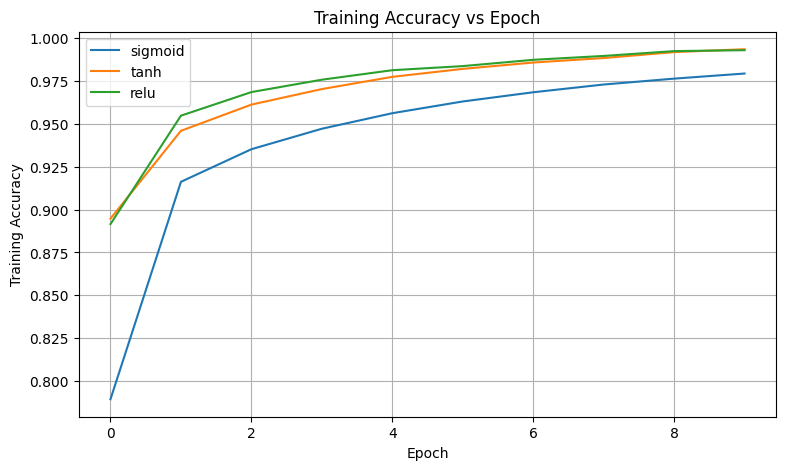

In [ ]:
plt.figure(figsize=(9, 5))

for activation in activations:
    plt.plot(
        histories[activation].history["accuracy"],
        label=activation
    )

plt.title("Training Accuracy vs Epoch")
plt.xlabel("Epoch")
plt.ylabel("Training Accuracy")
plt.legend()
plt.grid()
plt.show()

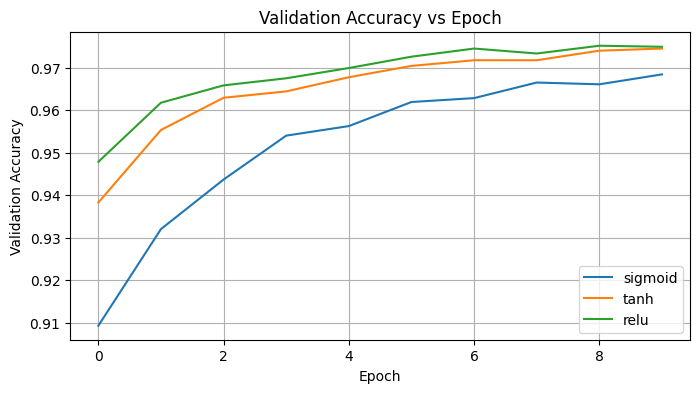

In [ ]:
plt.figure(figsize=(8, 4))

for activation in activations:
    plt.plot(
        histories[activation].history["val_accuracy"],
        label=activation
    )

plt.title("Validation Accuracy vs Epoch")
plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.legend()
plt.grid()
plt.show()

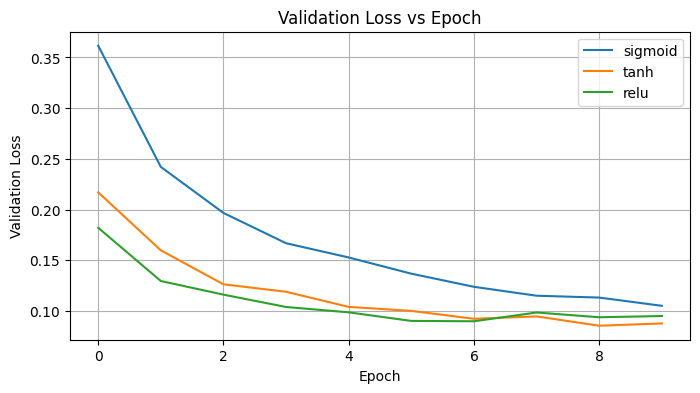

In [ ]:
plt.figure(figsize=(8, 4))

for activation in activations:
    plt.plot(
        histories[activation].history["val_loss"],
        label=activation
    )

plt.title("Validation Loss vs Epoch")
plt.xlabel("Epoch")
plt.ylabel("Validation Loss")
plt.legend()
plt.grid()
plt.show()

In [ ]:
ROLL_NO = "24BAD024"

print("Experiment No: 2")
print("Roll No:", ROLL_NO)


Experiment No: 2
Roll No: 24BAD024
